## Project: Diwali Sales Analysis

### Problem Statement

- The goal of this project was to understand customer purchasing patterns during the Diwali festival and identify the major factors that influence sales performance.
- This analysis helps businesses improve decision-making related to promotions, customer targeting, and inventory planning during festive seasons.

### Objective

The objective of this project was to explore Diwali sales data and uncover meaningful trends that explain who contributes most to revenue, which regions perform better, and which products are in higher demand during the festive period.

### Tools & Technologies Used

- Python
- Pandas & NumPy
- Matplotlib & Seaborn
- VS Code

### Key Insights

- A significant share of total revenue comes from a specific group of customers who shop more actively during Diwali.
- Customers belonging to the young and middle-age working population contribute the highest sales.
- Certain regions consistently generate higher orders and revenue compared to others.
- Customers with stable professional backgrounds tend to spend more during festive sales.
- A few product categories dominate overall sales and drive most of the revenue.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\91928\Downloads\Diwali Sales Data.csv",encoding="cp1252") # Read the csv file into a DataFrame
#to avoid encoding error, use cp1252

In [6]:
df.head()     # By Default First 5 Rows

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [7]:
df.tail()   # By Default Last 5 Rows

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.0,NaN,NaN


In [8]:
df.head(10)  # First 10 Rows

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [9]:
df.shape   # Row , Columns

(11251, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [11]:
df.drop(['Status','unnamed1'] , axis = 1 , inplace = True)
# drop unrelated/blank columns

In [12]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [13]:
pd.isnull(df).sum() #check for null values

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [14]:
df.shape

(11251, 13)

In [15]:
df.dropna(inplace =True) # inplace = true save the file

In [16]:
df.shape

(11239, 13)

In [17]:
pd.isnull(df).sum() #check for null values

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [18]:
# change data type of amount cloumn
df['Amount']=df['Amount'].astype('int')

In [19]:
# to check datatype
df['Amount'].dtypes

dtype('int64')

In [20]:
df.columns # to check columns name

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [21]:
# Rename marital_status column name to shadi
df.rename(columns= {'Marital_status':'Shadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [22]:
df.describe() 
# method returns description of the data in the dataframe(i.e count, mean, std, etc)

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [23]:
# use describe() for specific columns
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


### Exploratory Data Analysis (EDA)

#### Gender

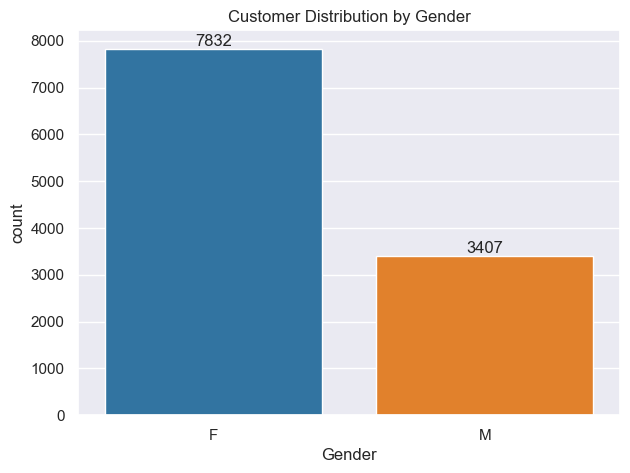

In [55]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x='Gender',hue='Gender', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Customer Distribution by Gender')
for bars in ax.containers:
    ax.bar_label(bars)

In [25]:
Sales_Gender = df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

In [26]:
Sales_Gender.head()

,Gender,Amount
0,F,74335853
1,M,31913276


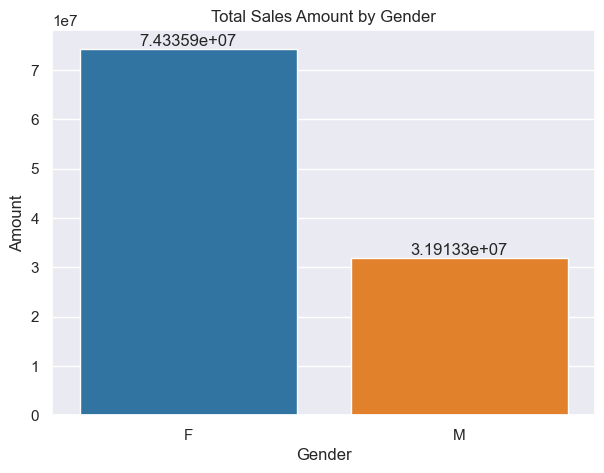

In [53]:
plt.figure(figsize=(7,5))
bx = sns.barplot(x ='Gender', y= 'Amount',data = Sales_Gender ,hue='Gender',palette=['#1f77b4', '#ff7f0e'])
plt.title('Total Sales Amount by Gender')

for bars in bx.containers: 
    bx.bar_label(bars) 

- From above graphs we can see that most of the buyers are female and even the purchasing power of female are greater than male

#### Age

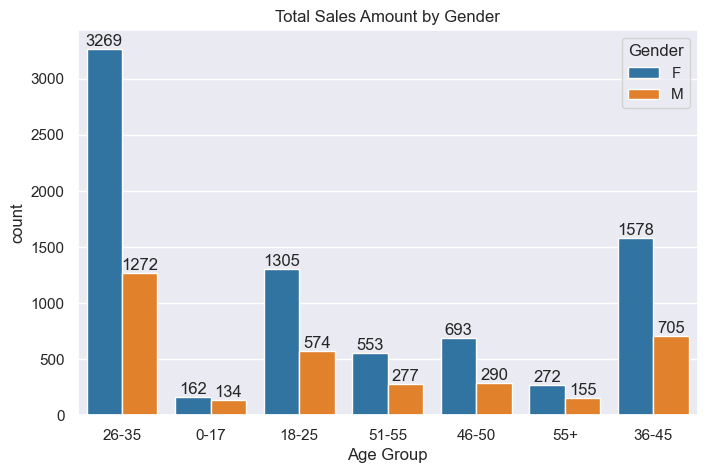

In [28]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data= df , x = 'Age Group', hue= 'Gender',palette=['#1f77b4', '#ff7f0e'])
plt.title('Total Sales Amount by Gender')

for bars in ax.containers: 
    ax.bar_label(bars) 
 

In [29]:
# total amount vs age group
Sales_Age = df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
Sales_Age.head()

,Age Group,Amount
2,26-35,42613442
3,36-45,22144994
1,18-25,17240732
4,46-50,9207844
5,51-55,8261477


Text(0.5, 1.0, 'Total Sales Amount by Age Group')

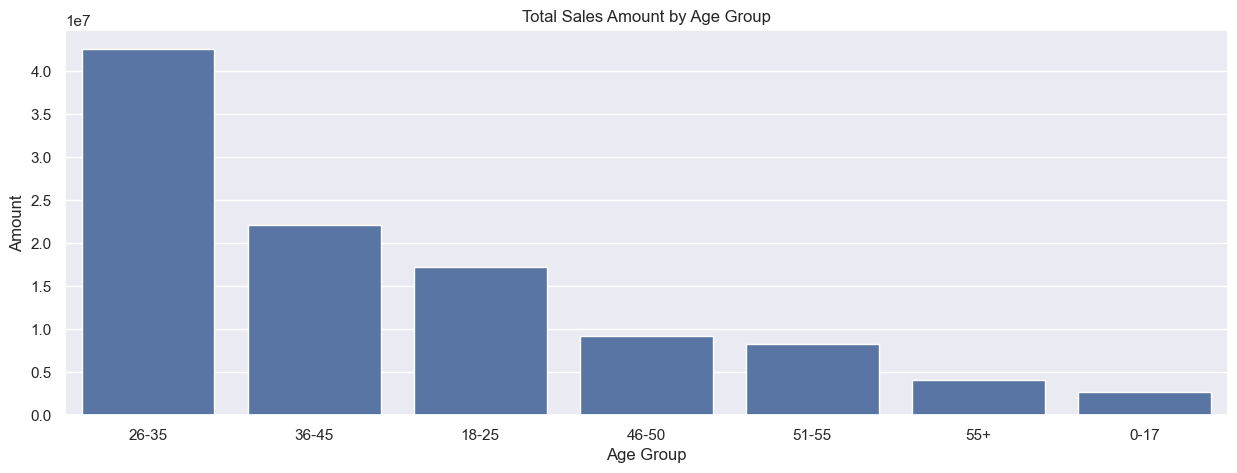

In [30]:
sns.barplot(x= 'Age Group',y= 'Amount',data = Sales_Age)
plt.title('Total Sales Amount by Age Group')

- From above graphs we can see that most of the buyers are of age group between 26-35 yrs Female

#### State

In [31]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [51]:
# Total number of Orders from top 10 states
Sales_State = df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending = False).head(10)

Text(0.5, 1.0, 'Top 10 States by Total Sales Order')

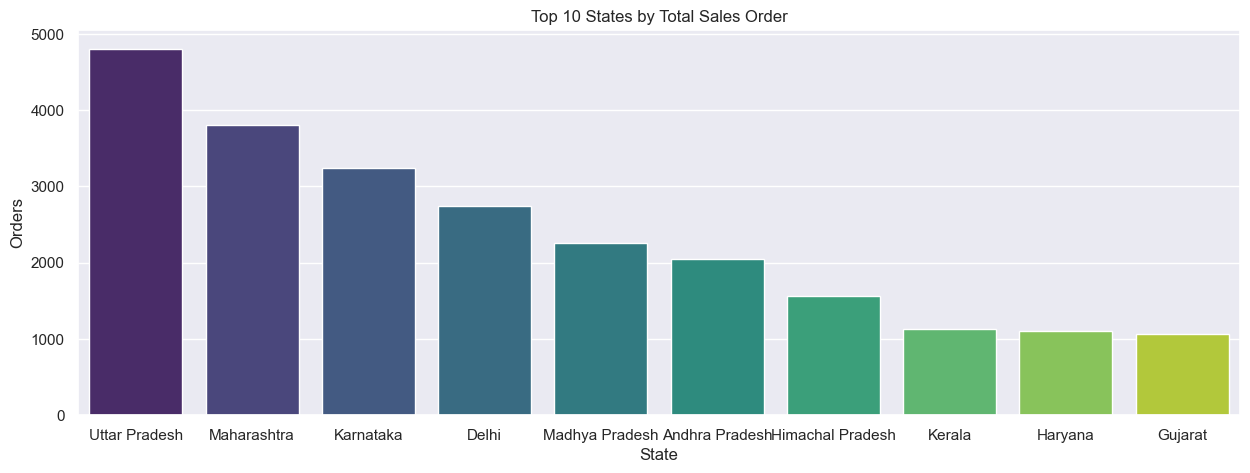

In [52]:
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = Sales_State , x ='State', y ='Orders',hue='State',palette ='viridis')
plt.title('Top 10 States by Total Sales Order')

In [34]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [35]:
# Total number of Amount from top 10 states
Sales_State = df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending = False).head(10)

Text(0.5, 1.0, 'Top 10 States by Total Sales Amount')

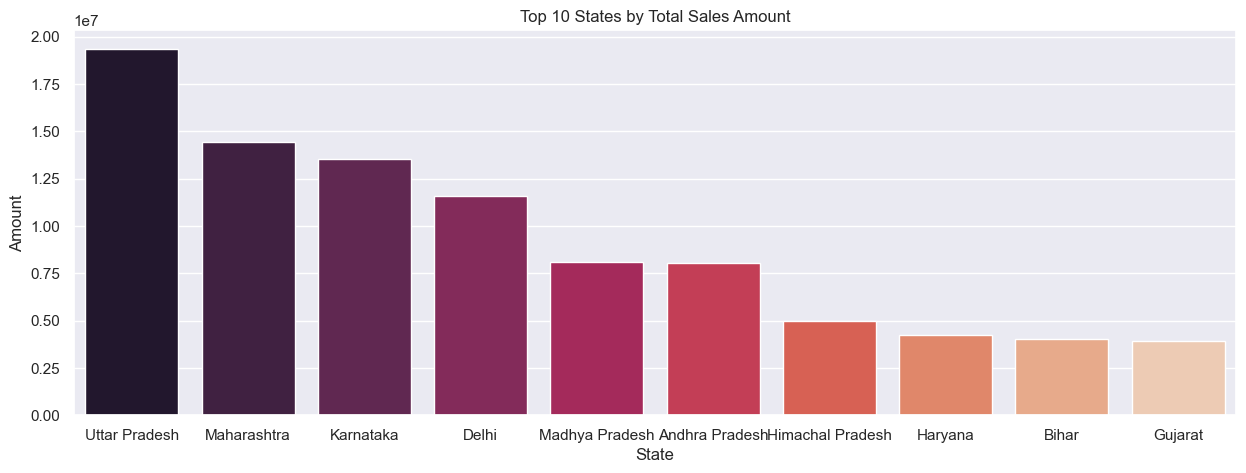

In [47]:
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data=Sales_State, x='State', y='Amount',hue='State',palette='rocket')
plt.title('Top 10 States by Total Sales Amount')

- From above graphs we can see that most of the orders &total sales/Amount are from uttar pradesh,Maharashtra and karnataka respectively

#### Marital Status

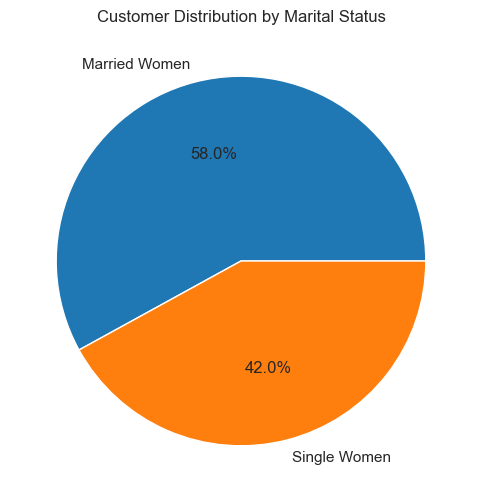

In [43]:
marital = df['Marital_Status'].map({0: 'Married Women', 1: 'Single Women'}).value_counts()
plt.figure(figsize=(6,6))
plt.pie(marital, labels=marital.index, autopct='%1.1f%%', colors=['#1f77b4','#ff7f0e'])
plt.title('Customer Distribution by Marital Status')
plt.show()

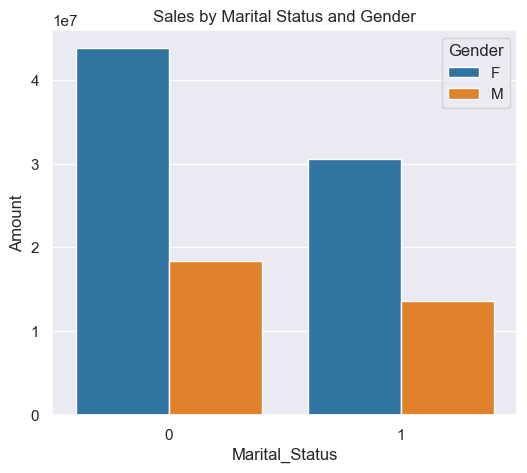

In [44]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize': (6,5)})
sns.barplot(data=sales_state, x='Marital_Status', y='Amount', hue='Gender',palette=['#1f77b4', '#ff7f0e'])
plt.title('Sales by Marital Status and Gender')
plt.show()


- From above graphs we can see  that most of the buyers are married (women)and they have high purchasing power

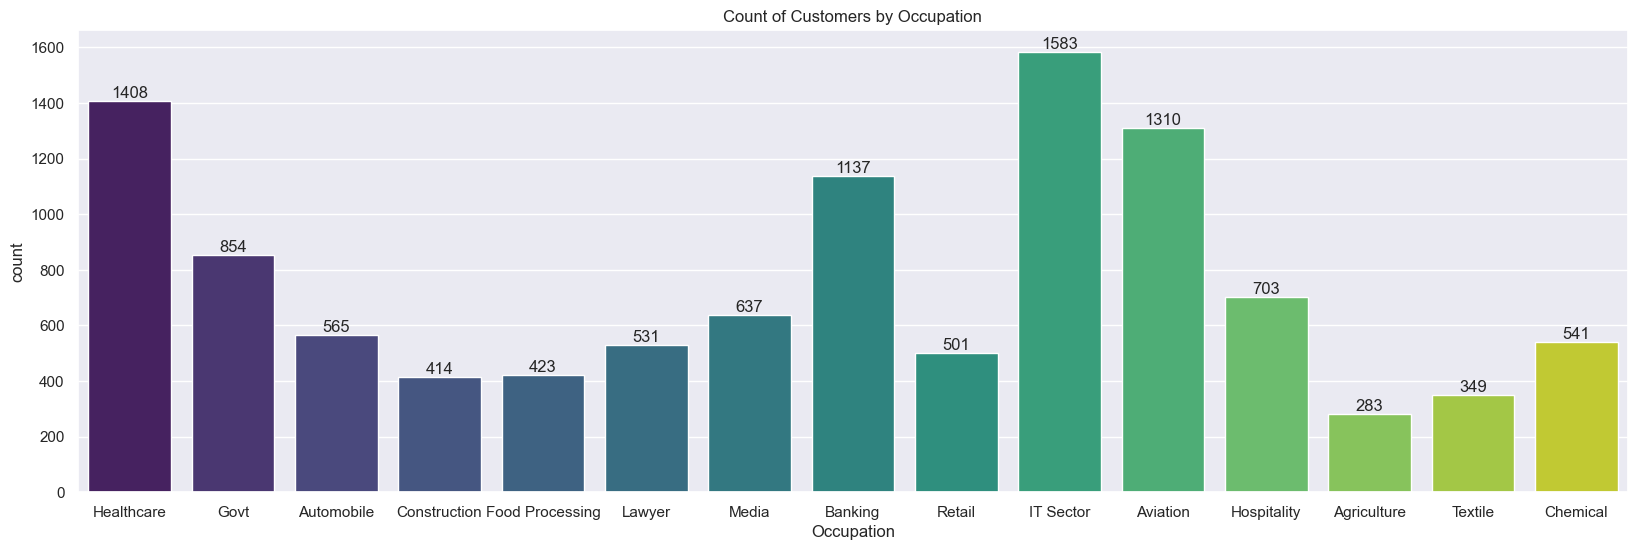

In [46]:
sns.set(rc={'figure.figsize':(20,6)})
ax= sns.countplot(data = df, x='Occupation',hue='Occupation',palette ='viridis',legend=False)
plt.title('Count of Customers by Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

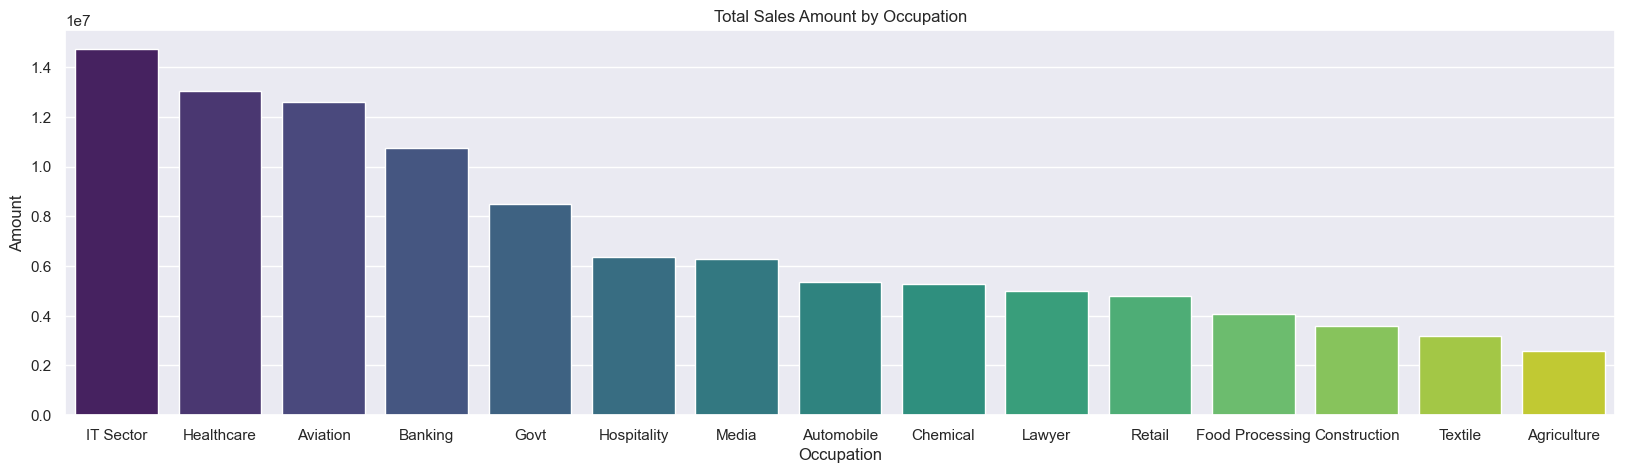

In [56]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.set(rc={'figure.figsize': (20,5)})
sns.barplot(data=sales_state, x='Occupation', y='Amount',hue='Occupation', palette='viridis')

plt.title('Total Sales Amount by Occupation')
plt.show()


- From above graphs we can see  that most of the buyers are working in IT, Healthcare sector and aviation

#### Products

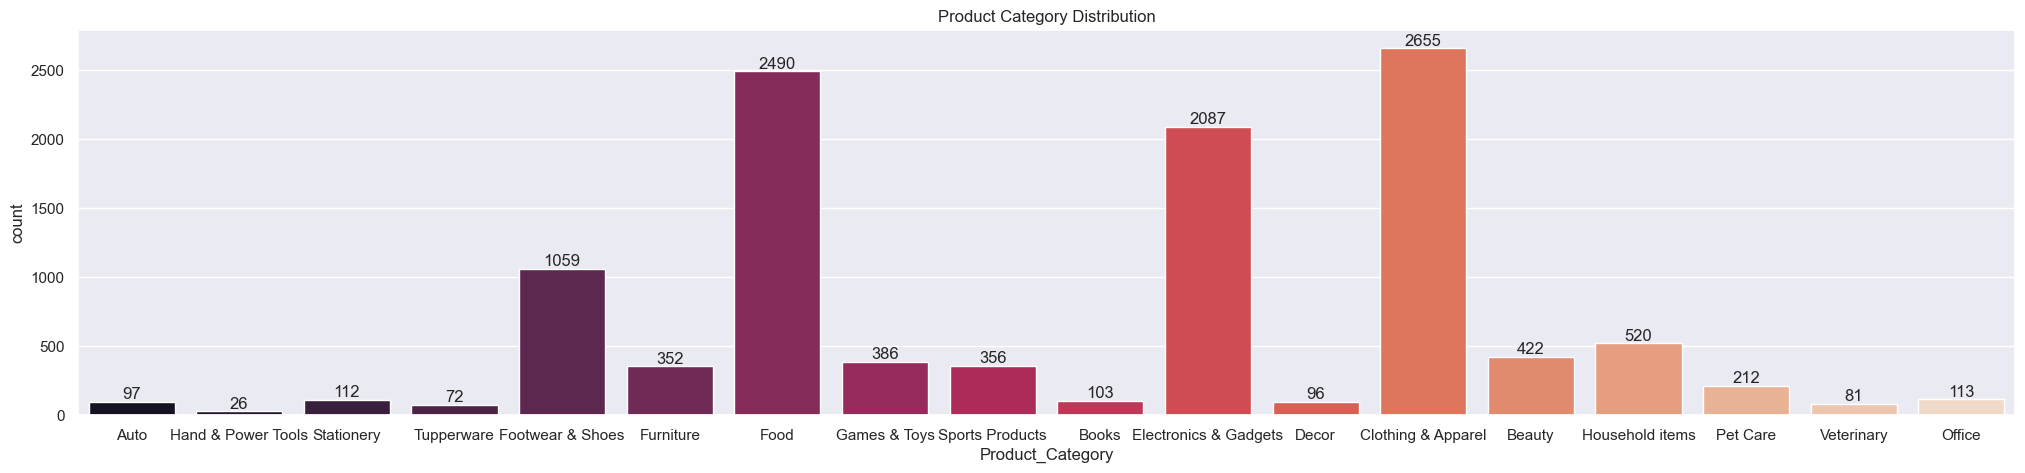

In [57]:
sns.set(rc={'figure.figsize': (25,5)})
ax = sns.countplot(data=df, x='Product_Category',hue='Product_Category',palette='rocket')

for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Product Category Distribution')
plt.show()


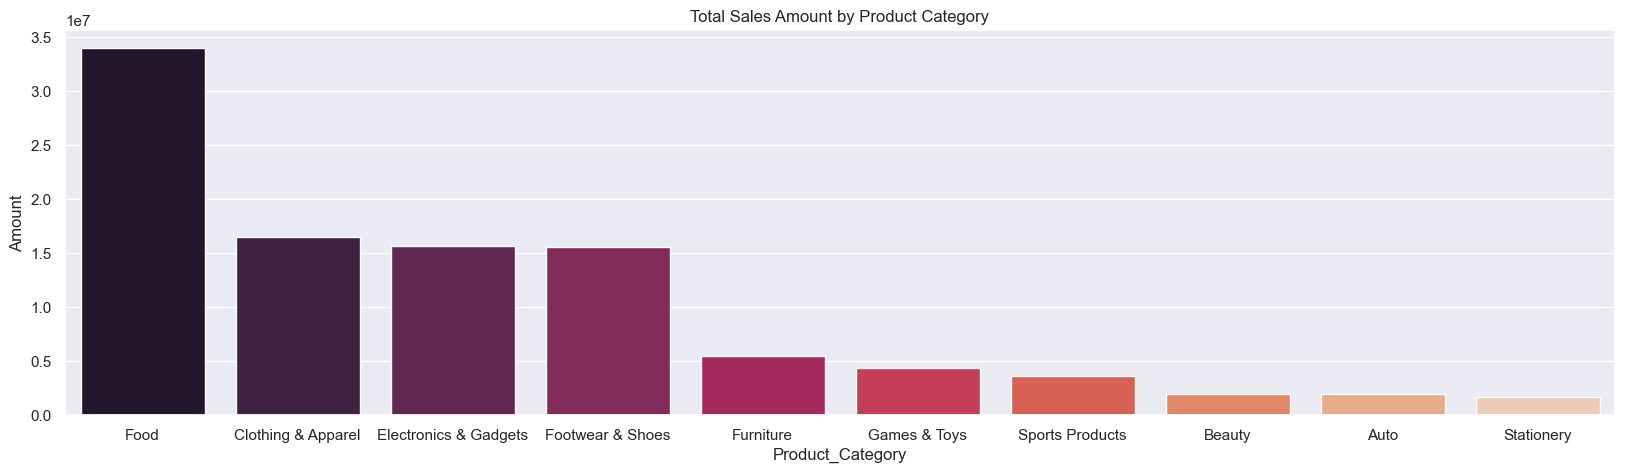

In [58]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize': (20,5)})
sns.barplot(data=sales_state, x='Product_Category', y='Amount',hue='Product_Category',palette='rocket')

plt.title('Total Sales Amount by Product Category')
plt.show()


- From above graphs we can see that most of the sold Product are from Food, clothing and elctronics category

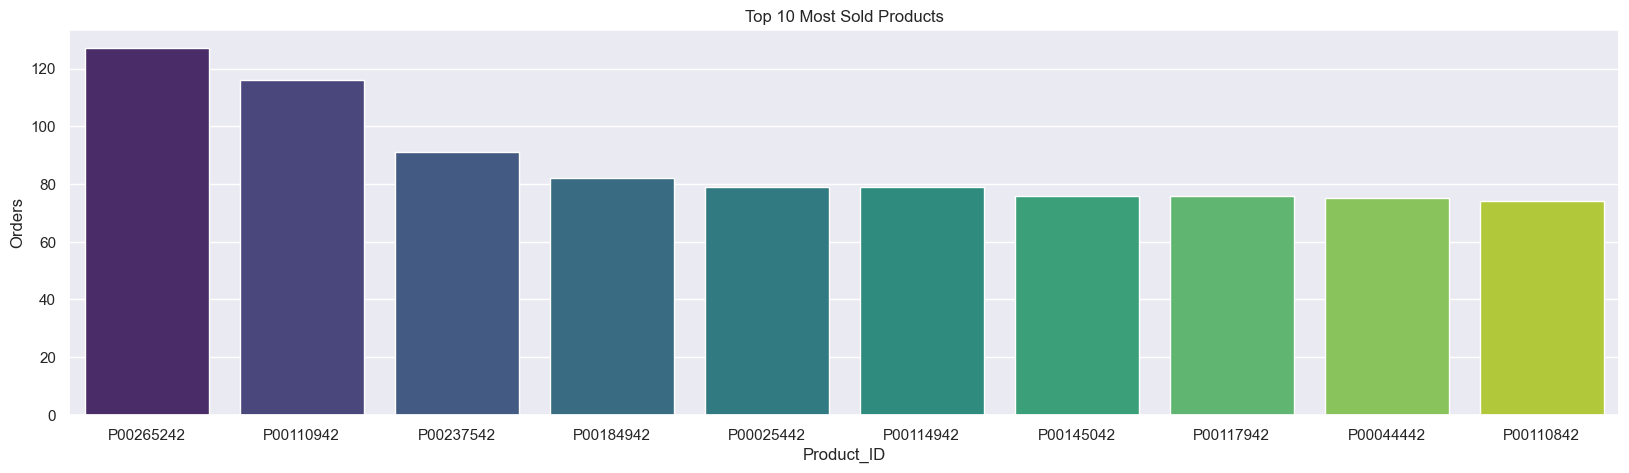

In [59]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize': (20,5)})
sns.barplot(data = sales_state, x='Product_ID', y='Orders', hue='Product_ID',palette ='viridis')
'Product_ID'
plt.title('Top 10 Most Sold Products')
plt.show()

### Conclusion:

Married women age group 26-35 yrs from UP, Maharashtra and Karnataka working in IT, Healthcare and Aviation are more likely to buy product from Food, Clothing and Electronics Category